In [1]:
import os
os.chdir("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipelines.catboost_pipe import CatBoostPipe
import pprint

pipe = CatBoostPipe()

In [29]:
trials = pipe.load("side_trials")
# hook = pipe.load("hook_ffd")[3] # verticals
hook = pipe.load("hook_f95")[3]
# pprint.pprint(f"N trials: {len(trials)}, trials:\n{trials}")
hook.columns

Index(['Side 11.11_0', 'Side 11.11_1', 'Side 11.11_2', 'Side 11.11_3',
       'Side 11.11_4', 'Side 11.11_5', 'Side 11.11_6', 'Side 11.11_7',
       'Side 11.11_8', 'Side 11.11_9', 'Side 11.11_10', 'Side 11.11_11',
       'Side 11.11_12', 'Side 11.11_13', 'Side 11.11_14', 'Side 11.11_15',
       'Side 11.11_16', 'Side 11.11_17', 'Side 11.11_18', 'Side 11.11_19',
       'Side 11.11_20', 'Side 11.11_21', 'Side 11.11_22', 'Side 11.11_23',
       'Side 11.11_24', 'Side 11.11_25', 'Side 11.11_26', 'Side 11.11_27',
       'Side 11.11_28', 'Side 11.11_29', 'Side 11.11_30', 'Side 11.11_31',
       'Side 11.11_32', 'Side 11.11_33', 'Side 11.11_34', 'Side 11.11_35',
       'Side 11.11_36', 'Side 11.11_37', 'Side 11.11_38', 'Side 11.11_39',
       'Side 11.11_40', 'Side 11.11_41', 'Side 11.11_42', 'Side 11.11_43',
       'Side 11.11_44', 'Side 11.11_45', 'Side 11.11_46', 'Side 11.11_47',
       'Side 11.11_48', 'Side 11.11_49', 'Side 11.11_50', 'Side 11.11_51',
       'Side 11.11_52', 'Side 11.11

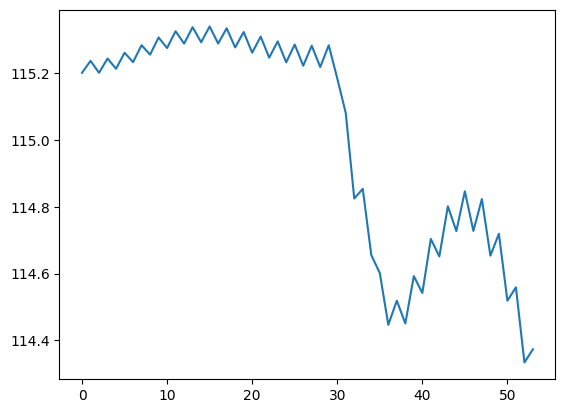

In [30]:
plt.plot(hook.iloc[:,1]/1000)

In [25]:
trials[1]

{'v': 40,
 'start_num': 547,
 'end_num': 552,
 'peaks': [10.058043479919434,
  6.79871129989624,
  9.143659591674805,
  0.7224913239479065,
  0.9551079273223877,
  1.1315101385116577,
  0.8228062391281128,
  2.087022542953491,
  1.8966795206069946,
  2.606165647506714,
  1.9429503679275513,
  2.5598948001861572,
  1.1035343408584595,
  0.8122126460075378,
  0.9502071142196655,
  0.7968798875808716,
  1.1835790872573853,
  2.146576404571533,
  1.9413474798202515,
  7.861413478851318,
  1.5437381267547607,
  0.764167070388794,
  1.198927879333496,
  0.7491753101348877,
  0.9732091426849365,
  0.9142167568206787,
  1.0027053356170654,
  0.884720504283905,
  1.0174535512924194,
  0.7346051335334778,
  0.7346051335334778,
  0.7346051335334778,
  0.8228062391281128,
  0.8081060647964478,
  3.0380265712738037,
  3.7012417316436768,
  3.3002278804779053,
  3.3619225025177,
  3.3156516551971436,
  6.592648983001709,
  1.1495325565338135,
  0.8735435605049133,
  0.7508817911148071,
  0.704883575

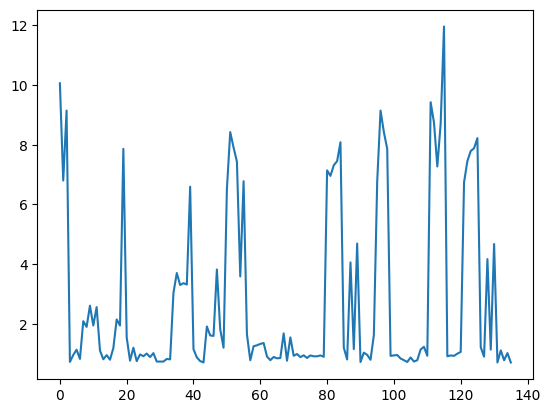

In [24]:
plt.plot(trials[1]["peaks"])

In [14]:
mask1 = np.array(trials[1]["peaks"]) <= 200
mask2 = np.array(trials[1]["peaks"]) >= 50

masked = np.where(mask1 & mask2)
masked

(array([], dtype=int64),)

In [4]:
filtered = np.array(trials[1]["peaks"])[masked]

In [5]:
# Load all hook simulations and collect peaks
from scipy.signal import find_peaks

hook_all = pipe.load("hook_ffd")
print(f"Number of hook simulations: {len(hook_all)}")

# Collect peaks from all simulations
all_peaks_from_simulations = []

# Process each simulation
for i, simulation in enumerate(hook_all):
    # Get all columns (each column is a different sensor/parameter)
    for col in simulation.columns:
        signal = simulation[col] / 1000  # Same scaling as before
        signal_clean = signal[~np.isnan(signal)].values
        
        # Find peaks
        peaks_idx, _ = find_peaks(signal_clean, height=0, distance=1)
        peaks_vals = signal_clean[peaks_idx]
        
        # Filter peaks (50-200)
        peaks_filtered = peaks_vals[(peaks_vals >= 50) & (peaks_vals <= 200)]
        all_peaks_from_simulations.extend(peaks_filtered.tolist())

all_peaks_from_simulations = np.array(all_peaks_from_simulations)
print(f"Total peaks found across all simulations: {len(all_peaks_from_simulations)}")

Number of hook simulations: 12
Total peaks found across all simulations: 10937


ИСХОДНЫЕ ВЕКТОРЫ: СИМУЛЯЦИЯ vs ИСПЫТАНИЯ

До интерполяции:
Длина вектора симуляции: 10937
Длина вектора испытаний: 86

После интерполяции:
Длина вектора симуляции: 10937
Длина вектора испытаний (интерполированных): 10937

Симуляция   - Mean: 147.5165, Std: 34.7511, Min: 51.8628, Max: 199.9961
Испытания   - Mean: 100.0919, Std: 18.7657, Min: 56.8340, Max: 178.7731


/tmp/ipykernel_18020/1469360107.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([real_interpolated, sim_sorted], labels=['Испытания', 'Симуляция'])


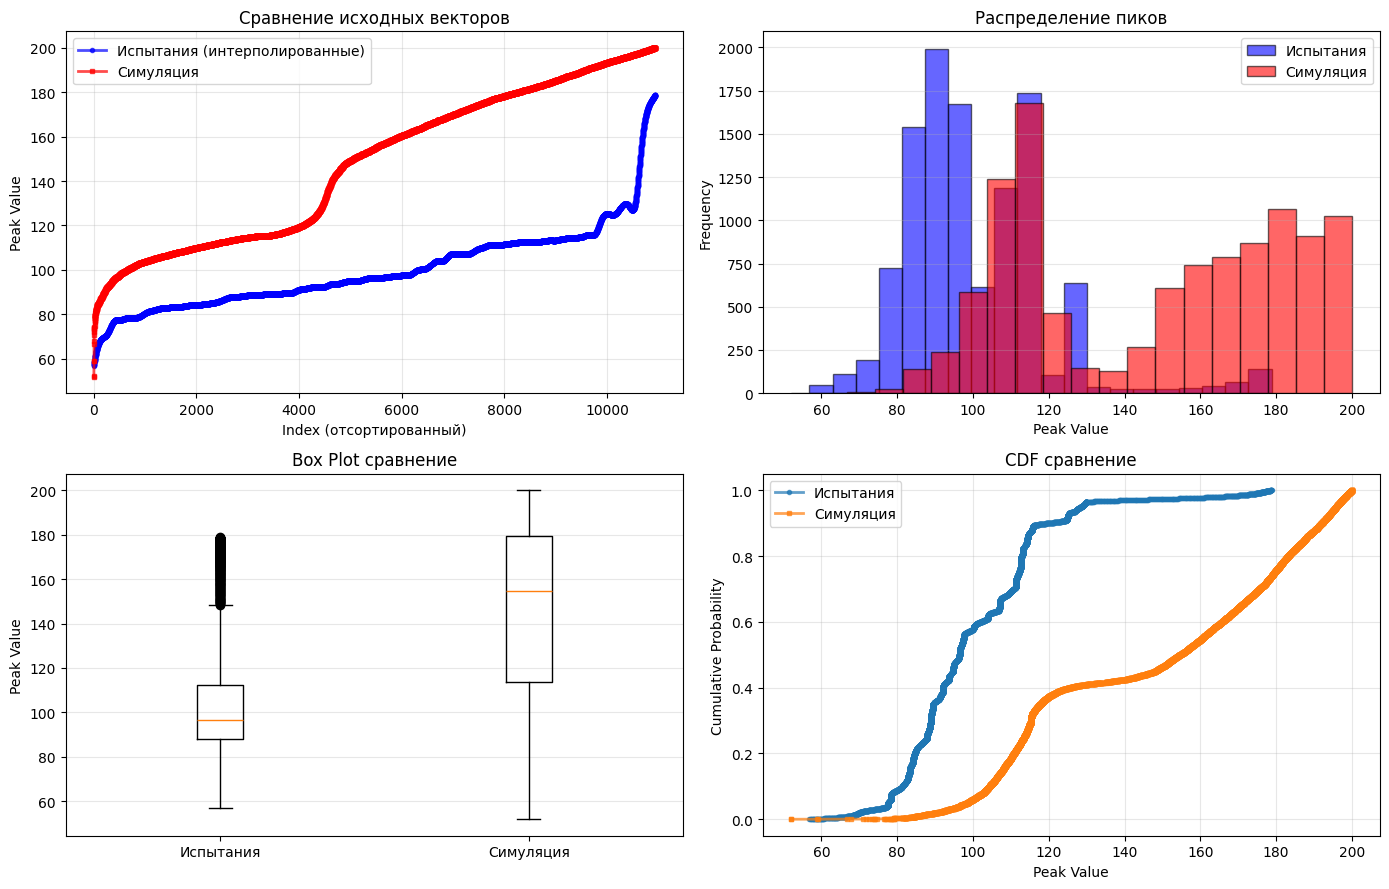

In [7]:
# Визуализация исходных векторов (без нормализации)
from scipy.interpolate import interp1d

print("="*70)
print("ИСХОДНЫЕ ВЕКТОРЫ: СИМУЛЯЦИЯ vs ИСПЫТАНИЯ")
print("="*70)

sim_sorted = np.sort(all_peaks_from_simulations)
real_sorted = np.sort(filtered)

print(f"\nДо интерполяции:")
print(f"Длина вектора симуляции: {len(sim_sorted)}")
print(f"Длина вектора испытаний: {len(real_sorted)}")

# Интерполируем испытания к размеру симуляции
x_old = np.linspace(0, 1, len(real_sorted))
x_new = np.linspace(0, 1, len(sim_sorted))
f_interp = interp1d(x_old, real_sorted, kind='cubic')
real_interpolated = f_interp(x_new)

print(f"\nПосле интерполяции:")
print(f"Длина вектора симуляции: {len(sim_sorted)}")
print(f"Длина вектора испытаний (интерполированных): {len(real_interpolated)}")

print(f"\nСимуляция   - Mean: {np.mean(sim_sorted):.4f}, Std: {np.std(sim_sorted):.4f}, Min: {np.min(sim_sorted):.4f}, Max: {np.max(sim_sorted):.4f}")
print(f"Испытания   - Mean: {np.mean(real_interpolated):.4f}, Std: {np.std(real_interpolated):.4f}, Min: {np.min(real_interpolated):.4f}, Max: {np.max(real_interpolated):.4f}")

# График исходных векторов
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Plot 1: Оба вектора на одном графике
axes[0, 0].plot(real_interpolated, 'o-', label='Испытания (интерполированные)', linewidth=2, markersize=3, alpha=0.7, color='blue')
axes[0, 0].plot(sim_sorted, 's-', label='Симуляция', linewidth=2, markersize=3, alpha=0.7, color='red')
axes[0, 0].set_xlabel('Index (отсортированный)')
axes[0, 0].set_ylabel('Peak Value')
axes[0, 0].set_title('Сравнение исходных векторов')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Гистограммы
axes[0, 1].hist(real_interpolated, bins=20, alpha=0.6, label='Испытания', edgecolor='black', color='blue')
axes[0, 1].hist(sim_sorted, bins=20, alpha=0.6, label='Симуляция', edgecolor='black', color='red')
axes[0, 1].set_xlabel('Peak Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Распределение пиков')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Box plot
axes[1, 0].boxplot([real_interpolated, sim_sorted], labels=['Испытания', 'Симуляция'])
axes[1, 0].set_ylabel('Peak Value')
axes[1, 0].set_title('Box Plot сравнение')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: CDF
sorted_real_interp = np.sort(real_interpolated)
sorted_sim = np.sort(sim_sorted)
axes[1, 1].plot(sorted_real_interp, np.arange(1, len(sorted_real_interp)+1)/len(sorted_real_interp), marker='o', label='Испытания', linewidth=2, markersize=3, alpha=0.7)
axes[1, 1].plot(sorted_sim, np.arange(1, len(sorted_sim)+1)/len(sorted_sim), marker='s', label='Симуляция', linewidth=2, markersize=3, alpha=0.7)
axes[1, 1].set_xlabel('Peak Value')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('CDF сравнение')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Нормализация и сравнение векторов
print("="*70)
print("ПОЭЛЕМЕНТНОЕ СРАВНЕНИЕ ВЕКТОРОВ: СИМУЛЯЦИЯ vs РЕАЛЬНЫЕ ИСПЫТАНИЯ")
print("="*70)

# Выравняем векторы по минимальной длине
min_len = min(len(sim_sorted), len(real_interpolated))
sim_aligned = sim_sorted[:min_len]
real_aligned = real_interpolated[:min_len]

print(f"\nВыравнены по минимальной длине: {min_len}")

# Нормализуем оба вектора к одинаковым статистическим характеристикам
mean_real = np.mean(real_aligned)
std_real = np.std(real_aligned)
mean_sim = np.mean(sim_aligned)
std_sim = np.std(sim_aligned)

# Стандартизируем и приводим симуляцию к параметрам испытаний
sim_normalized = ((sim_aligned - mean_sim) / std_sim) * std_real + mean_real

print(f"\n--- СТАТИСТИКА ИСХОДНЫХ ВЕКТОРОВ ---")
print(f"Испытания   - Mean: {mean_real:.4f}, Std: {std_real:.4f}")
print(f"Симуляция   - Mean: {mean_sim:.4f}, Std: {std_sim:.4f}")

print(f"\n--- СТАТИСТИКА НОРМАЛИЗОВАННОЙ СИМУЛЯЦИИ ---")
print(f"Нор.Симуляция - Mean: {np.mean(sim_normalized):.4f}, Std: {np.std(sim_normalized):.4f}")
print(f"(Приведена к параметрам испытаний)")

# Рассчитаем отклонения ПОСЛЕ нормализации
absolute_errors_after = sim_normalized - real_aligned
relative_errors_after = (absolute_errors_after / real_aligned) * 100
absolute_errors_abs_after = np.abs(absolute_errors_after)
relative_errors_abs_after = np.abs(relative_errors_after)

# Улучшение после нормализации
relative_errors_before = (np.abs(sim_aligned - real_aligned) / real_aligned) * 100
improvement_pct = ((np.mean(np.abs(relative_errors_before)) - np.mean(relative_errors_abs_after)) / np.mean(np.abs(relative_errors_before))) * 100
print(f"\n>>> Улучшение погрешности после нормализации: {improvement_pct:.2f}%")

# Процентиль ошибок
print(f"\n--- РАСПРЕДЕЛЕНИЕ ОШИБОК (абсолютных) ПОСЛЕ НОРМАЛИЗАЦИИ ---")
for p in [10, 25, 50, 75, 90]:
    val = np.percentile(absolute_errors_abs_after, p)
    print(f"{p}th percentile: {val:.4f}")

# Таблица сравнения (первые и последние 10 элементов)
print(f"\n--- ТАБЛИЦА СРАВНЕНИЯ (НОРМАЛИЗОВАННАЯ СИМУЛЯЦИЯ) ---")
print(f"{'#':<5} {'Испытание':<15} {'Нор.Симуляция':<15} {'Абс.Отклон':<15} {'Отн.Отклон':<15}")
print("-" * 70)

# Первые 10
for i in range(min(10, min_len)):
    print(f"{i+1:<5} {real_aligned[i]:<15.4f} {sim_normalized[i]:<15.4f} {absolute_errors_after[i]:<15.4f} {relative_errors_after[i]:>6.2f}%")

if min_len > 20:
    print("...")
    
# Последние 10
for i in range(max(0, min_len-10), min_len):
    print(f"{i+1:<5} {real_aligned[i]:<15.4f} {sim_normalized[i]:<15.4f} {absolute_errors_after[i]:<15.4f} {relative_errors_after[i]:>6.2f}%")

# Расхождение между двумя векторами
print(f"\n{'='*70}")
print(f"ПРОЦЕНТНОЕ РАСХОЖДЕНИЕ МЕЖДУ ВЕКТОРАМИ")
print(f"{'='*70}")

# MAPE - Mean Absolute Percentage Error (%)
mape_after = np.mean(relative_errors_abs_after)
print(f"\n1. Среднее абсолютное процентное отклонение (MAPE): {mape_after:.2f}%")

# RMSE в процентах от среднего значения
rmse_after = np.sqrt(np.mean(absolute_errors_after**2))
rmse_pct_after = (rmse_after / np.mean(real_aligned)) * 100
print(f"2. RMSE (в % от среднего): {rmse_pct_after:.2f}%")

# Максимальное отклонение в %
max_rel_error_after = np.max(relative_errors_abs_after)
print(f"3. Максимальное отклонение: {max_rel_error_after:.2f}%")

# Медианное отклонение в %
median_rel_error_after = np.median(relative_errors_abs_after)
print(f"4. Медианное отклонение: {median_rel_error_after:.2f}%")

# Процент элементов с ошибкой менее 5%, 10%, 15%
elements_under_5pct = np.sum(relative_errors_abs_after < 5) / len(relative_errors_abs_after) * 100
elements_under_10pct = np.sum(relative_errors_abs_after < 10) / len(relative_errors_abs_after) * 100
elements_over_15pct = np.sum(relative_errors_abs_after > 15) / len(relative_errors_abs_after) * 100

print(f"\n5. Распределение элементов по порогам:")
print(f"   - Элементов с ошибкой < 5%: {elements_under_5pct:.1f}%")
print(f"   - Элементов с ошибкой < 10%: {elements_under_10pct:.1f}%")
print(f"   - Элементов с ошибкой > 15%: {elements_over_15pct:.1f}%")

# Интегральная оценка схожести
similarity_score = 100 - mape_after
print(f"\n>>> ОБЩАЯ СХОЖЕСТЬ ВЕКТОРОВ: {similarity_score:.2f}%")
print(f">>> ОБЩЕЕ РАСХОЖДЕНИЕ ВЕКТОРОВ: {mape_after:.2f}%")

ПОЭЛЕМЕНТНОЕ СРАВНЕНИЕ ВЕКТОРОВ: СИМУЛЯЦИЯ vs РЕАЛЬНЫЕ ИСПЫТАНИЯ

Выравнены по минимальной длине: 10937

--- СТАТИСТИКА ИСХОДНЫХ ВЕКТОРОВ ---
Испытания   - Mean: 100.0919, Std: 18.7657
Симуляция   - Mean: 147.5165, Std: 34.7511

--- СТАТИСТИКА НОРМАЛИЗОВАННОЙ СИМУЛЯЦИИ ---
Нор.Симуляция - Mean: 100.0919, Std: 18.7657
(Приведена к параметрам испытаний)

>>> Улучшение погрешности после нормализации: 86.69%

--- РАСПРЕДЕЛЕНИЕ ОШИБОК (абсолютных) ПОСЛЕ НОРМАЛИЗАЦИИ ---
10th percentile: 2.7786
25th percentile: 4.5714
50th percentile: 5.7147
75th percentile: 6.9564
90th percentile: 8.6583

--- ТАБЛИЦА СРАВНЕНИЯ (НОРМАЛИЗОВАННАЯ СИМУЛЯЦИЯ) ---
#     Испытание       Нор.Симуляция   Абс.Отклон      Отн.Отклон     
----------------------------------------------------------------------
1     56.8340         48.4387         -8.3954         -14.77%
2     57.0036         48.5577         -8.4459         -14.82%
3     57.1715         52.1931         -4.9783          -8.71%
4     57.3378         52.316

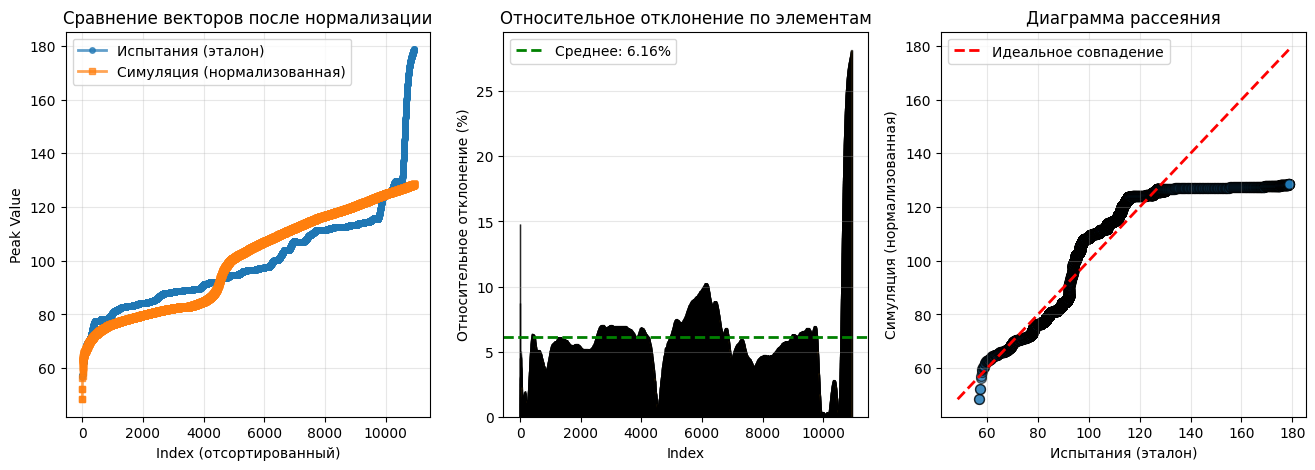

In [10]:
# Визуализация отклонений
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Оба вектора на одном графике
axes[0].plot(real_aligned, 'o-', label='Испытания (эталон)', linewidth=2, markersize=4, alpha=0.7)
axes[0].plot(sim_normalized, 's-', label='Симуляция (нормализованная)', linewidth=2, markersize=4, alpha=0.7)
axes[0].set_xlabel('Index (отсортированный)')
axes[0].set_ylabel('Peak Value')
axes[0].set_title('Сравнение векторов после нормализации')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Относительное отклонение
axes[1].bar(np.arange(min_len), relative_errors_abs_after, color='orange', alpha=0.6, edgecolor='black')
axes[1].axhline(y=np.mean(relative_errors_abs_after), color='green', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(relative_errors_abs_after):.2f}%')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Относительное отклонение (%)')
axes[1].set_title('Относительное отклонение по элементам')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Диаграмма рассеяния
axes[2].scatter(real_aligned, sim_normalized, alpha=0.6, s=50, edgecolors='black')
min_val = min(np.min(real_aligned), np.min(sim_normalized))
max_val = max(np.max(real_aligned), np.max(sim_normalized))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное совпадение')
axes[2].set_xlabel('Испытания (эталон)')
axes[2].set_ylabel('Симуляция (нормализованная)')
axes[2].set_title('Диаграмма рассеяния')
axes[2].legend()
axes[2].grid(True, alpha=0.3)